# Data Pre-Processing

## Module Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from sklearn.impute import KNNImputer

## Data Import

In [11]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

df = torch.load(chunksFilePath / 'SampledData-10Percent.pth', map_location="cpu", weights_only=False)

In [12]:
# Reorder columns to move imgData to the end
cols = [col for col in df.columns if col != 'imgData'] + ['imgData']
df = df[cols]

geoVars = ['latitude', 'longitude', 'elevation', 'slope', 'aspect']
levelVars = ['level0', 'level1_family', 'level2_genus', 'level3_species']
numericCols = [col for col in df.columns if col not in levelVars + ['ID', 'imgData']]

# Small Classes

- Will be very hard to predict and just add noise

In [13]:
intialDFShape = df.shape

minClassSize = 5

# remove rows with level3_species that occur rarely in entire df
speciesCounts = df['level3_species'].value_counts()
speciesToKeep = speciesCounts[speciesCounts > minClassSize].index
df = df[df['level3_species'].isin(speciesToKeep)]

In [30]:
# validate smallest class sizes per level
valueCounts = []

for level in levelVars:
    vc = df[level].value_counts().reset_index()
    vc.columns = [level, 'count']
    vc['level'] = level
    valueCounts.append(vc)

# minimum value frequency per level
for vc in valueCounts:
    min_count = vc['count'].min()
    level = vc['level'].iloc[0]
    print(f"Minimum frequency for {level}: {min_count}, occurrences: {vc[vc['count'] == min_count].shape[0]}")

Minimum frequency for level0: 2452, occurrences: 1
Minimum frequency for level1_family: 6, occurrences: 3
Minimum frequency for level2_genus: 6, occurrences: 46
Minimum frequency for level3_species: 6, occurrences: 319


# Outliers

## Numeric Predictors
- Do not winsorisation geographic variables due to real world meaning
    - and no obvious outliers from inspection
- very mild winsorisation as few obvious outliers, many varaibles with heavy tails

In [31]:
colsToWins = [col for col in df.columns if col not in geoVars+levelVars+['ID', 'imgData']]

colsToWinsRangesBefore = df[colsToWins].max() - df[colsToWins].min()

winsPercentile = 0.005

for col in colsToWins:
    lower = df[col].quantile(winsPercentile)
    upper = df[col].quantile(1 - winsPercentile)
    df[col] = df[col].clip(lower=lower, upper=upper)

colsToWinsRangesAfter = df[colsToWins].max() - df[colsToWins].min()

#range reduction ratios
colsRRR = colsToWinsRangesBefore / colsToWinsRangesAfter
colsRRR = colsRRR.sort_values(ascending=False)

(0.0, 4.648636531829834)

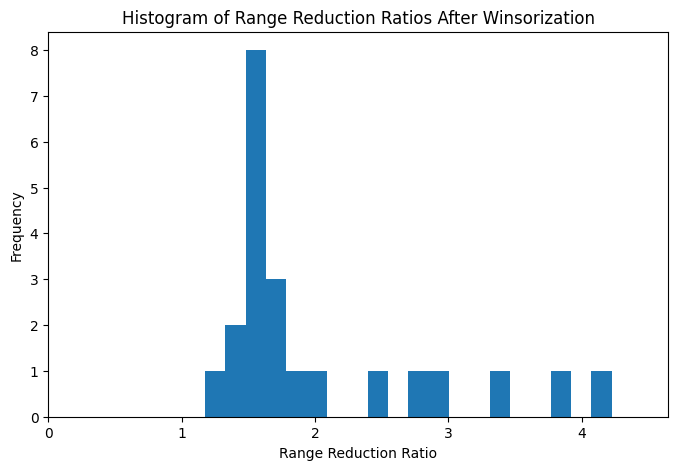

In [32]:
figColRR, axColRR = plt.subplots(figsize=(8, 5))
axColRR.hist(colsRRR, bins=20)
axColRR.set_title('Histogram of Range Reduction Ratios After Winsorization')
axColRR.set_xlabel('Range Reduction Ratio')
axColRR.set_ylabel('Frequency')
axColRR.set_xlim(0, max(colsRRR)*1.1)

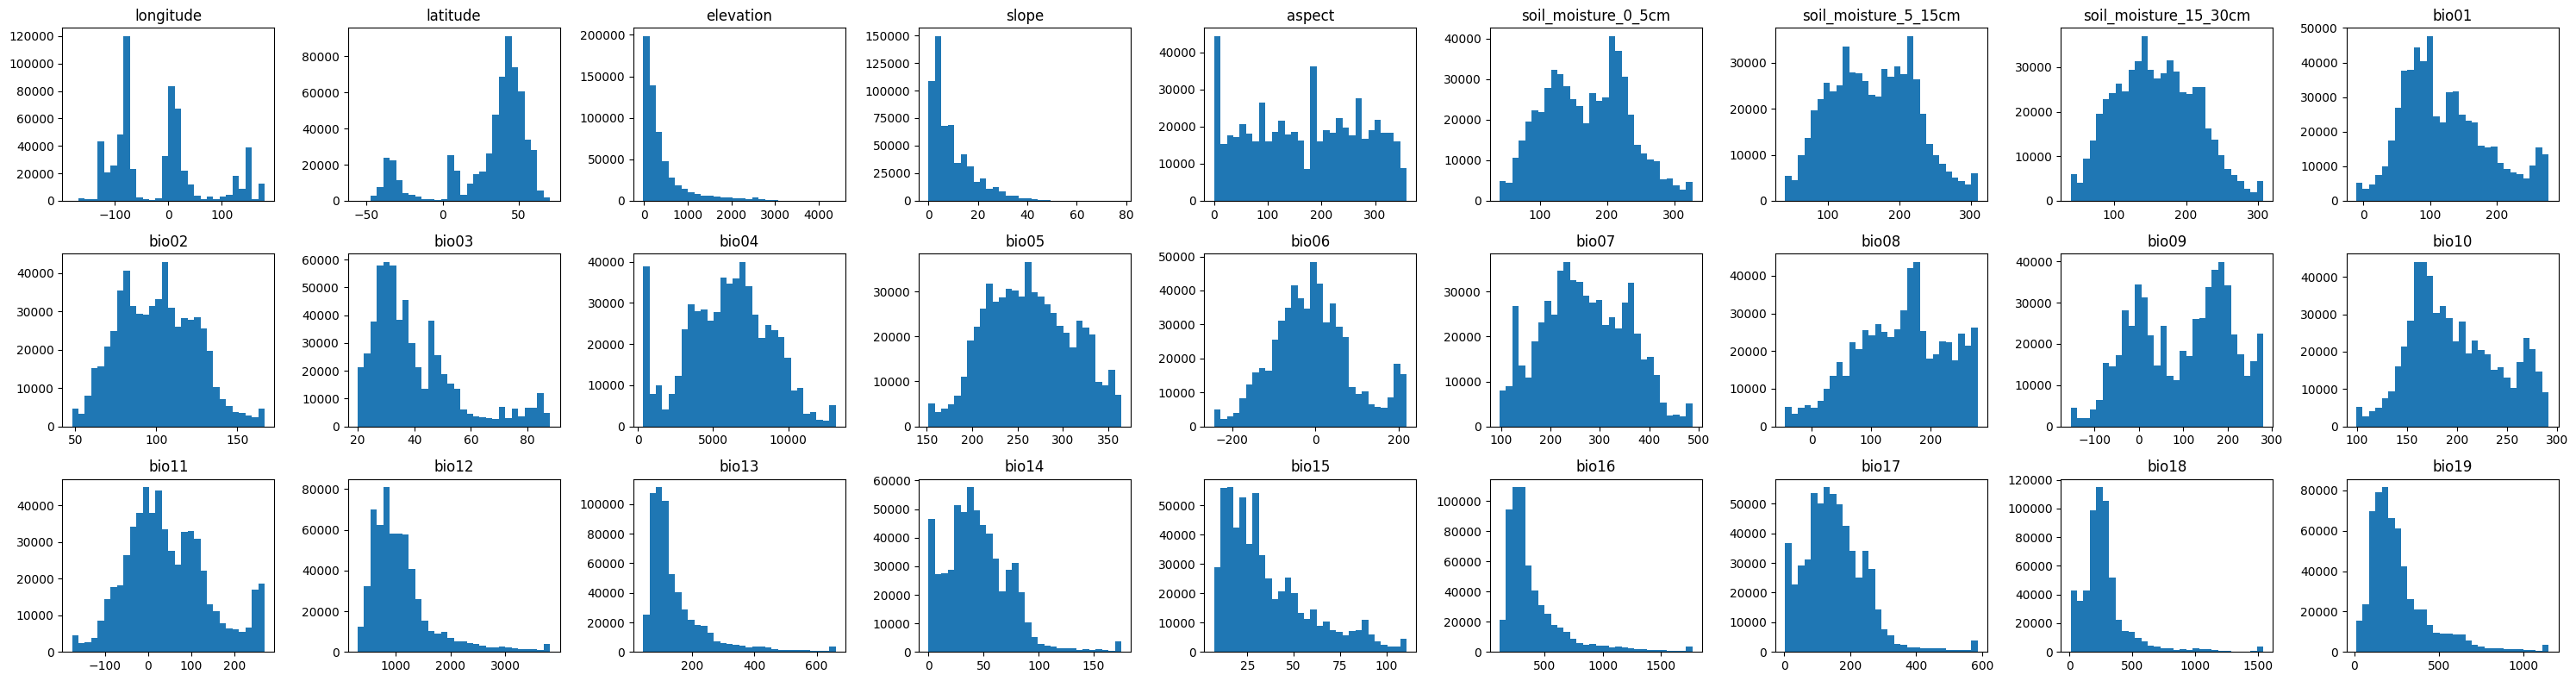

In [33]:
figDist, axDist = plt.subplots(nrows = 3, ncols=9, figsize=(30,8))

for i, col in enumerate(numericCols):
    a = i // 9
    b = i % 9
    ax = axDist[a, b]
    ax.hist(df[col].dropna().values, bins=30)
    ax.set_title(col)

figDist.tight_layout()

Tails notably reduced

## Image Data

- All distributions are heavily right skewed so winsorise on that tail only

In [34]:
allImgData = torch.stack(list(df['imgData'].values), dim=0)
allImgDataFlat = allImgData.view(-1, allImgData.shape[2])
allImgDataFlat.shape

torch.Size([7259496, 10])

In [35]:
# Min/max per band ignoring NaNs (compatible with older torch)
mask = ~torch.isnan(allImgDataFlat)
safe_min = torch.where(mask, allImgDataFlat, torch.tensor(float('inf')))
safe_max = torch.where(mask, allImgDataFlat, torch.tensor(float('-inf')))
band_min = safe_min.min(dim=0).values
band_max = safe_max.max(dim=0).values

imgRangesBefore = band_max - band_min


imgQuant_upper = torch.zeros(allImgDataFlat.shape[1])

for i in range(allImgDataFlat.shape[1]):
    band_data = allImgDataFlat[:, i]
    # Filter out NaNs
    valid_data = band_data[~torch.isnan(band_data)]
    imgQuant_upper[i] = torch.quantile(valid_data, 1 - winsPercentile*2)



In [36]:
# Apply winsorization to each tensor in df['imgData'] using per-band quantiles
def winsorize_tensor(t, upper_bounds):
    """Apply per-band winsorization to a tensor, preserving NaNs"""
    t_wins = t.clone()
    for i in range(t.shape[1]):  # iterate over bands (columns)
        t_wins[:, i] = torch.clamp(t_wins[:, i],  max=upper_bounds[i])
    return t_wins


df['imgData'] = df['imgData'].apply(lambda t: winsorize_tensor(t, imgQuant_upper))

allImgData_wins = torch.stack(list(df['imgData'].values), dim=0)
allImgDataFlat_wins = allImgData_wins.view(-1, allImgData_wins.shape[2])

# Check ranges after winsorization
safe_min_after = torch.where(~torch.isnan(allImgDataFlat_wins), allImgDataFlat_wins, torch.tensor(float('inf')))
safe_max_after = torch.where(~torch.isnan(allImgDataFlat_wins), allImgDataFlat_wins, torch.tensor(float('-inf')))
band_min_after = safe_min_after.min(dim=0).values
band_max_after = safe_max_after.max(dim=0).values
imgRangesAfter = band_max_after - band_min_after

imgRangesBefore / imgRangesAfter

tensor([2.9800, 2.9147, 2.8697, 2.4598, 4.2637, 2.5667, 2.5309, 2.4978, 3.2693,
        3.8789], dtype=torch.float64)

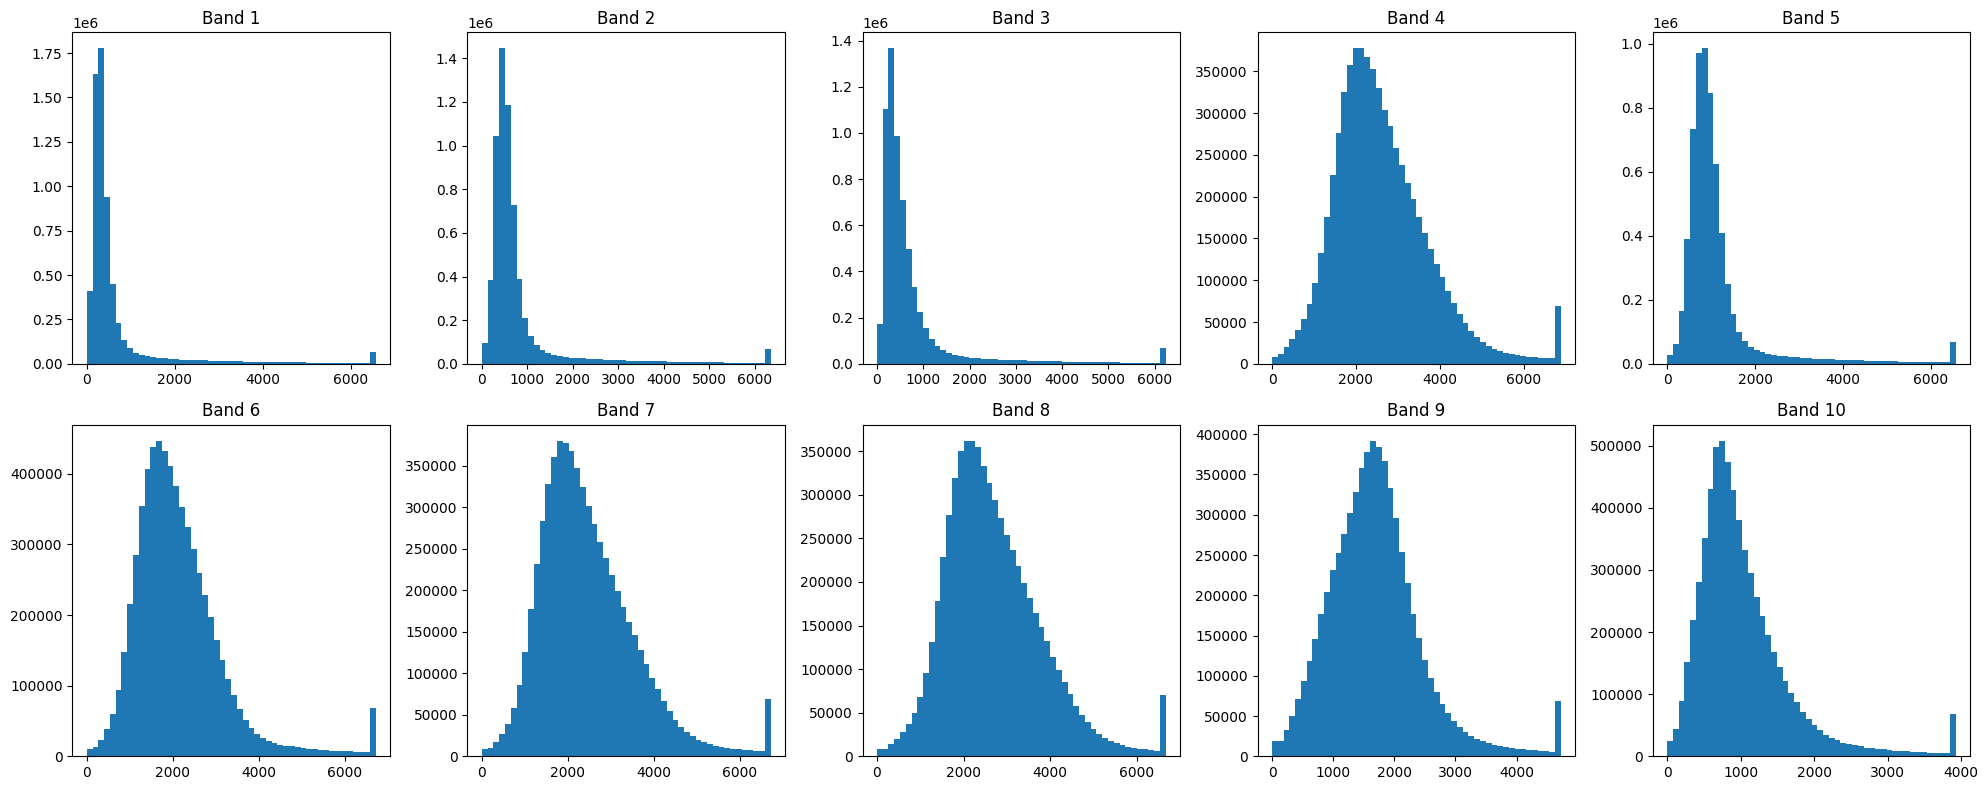

In [37]:
figImgDist, axImgDist = plt.subplots(nrows=2, ncols=5, figsize=(20,8))

for i in range(allImgDataFlat_wins.shape[1]):
    ax = axImgDist[i // 5, i % 5]
    ax.hist(allImgDataFlat_wins[:, i].numpy(), bins=50)
    ax.set_title(f'Band {i+1}')
    #ax.set_xscale('log')

figImgDist.tight_layout()

Significant improvement in distribution shape, bands 1-3 still are quite narrow

# Missing Values

## Numeric Predictors

In [14]:
rowMissingProp = df[numericCols].isna().sum(axis=1)/df[numericCols].shape[1]
rowMissingPropNo0 = rowMissingProp[rowMissingProp != 0.0]

rowMissingProp.describe()

count    604958.000000
mean          0.025066
std           0.113800
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
dtype: float64

In [15]:
# drop rows with misingness greater than 50%
mask = rowMissingProp.loc[df.index] <= 0.5
df = df.loc[mask]
print(f"Dropped {intialDFShape[0] - df.shape[0]} rows with >50% missing numeric data.")

# Recalculate numericCols after filtering to match current dataframe
numericCols = [col for col in df.columns if col not in levelVars + ['ID', 'imgData']]

# KNN imputation filtered by species for other missing numeric data
def impute_species_group(group):
    """Impute missing values within a species group"""
    group = group.copy()

    # Skip groups that are too small
    if group.shape[0] < 6:
        return group
    
    


    # Define numeric columns within this function to avoid scope issues
    cols_to_impute = [col for col in group.columns
    if col not in levelVars + ['ID', 'imgData']
    and not group[col].isna().all()]

    valid_rows = group[cols_to_impute].notna().any(axis=1).sum()
    if valid_rows <= 5:
        return group
    
    k = min(5, group.shape[0] - 1)
    imputer = KNNImputer(n_neighbors=k, weights='distance')

    imputed_array = imputer.fit_transform(group[cols_to_impute])
    
    # Assign imputed values back using iloc
    imputed_df = pd.DataFrame(imputed_array, columns=cols_to_impute, index=group.index)
    group[cols_to_impute] = imputed_df
    
    return group

print("Missing values before species-grouped KNN imputation:")
print(df[numericCols].isna().sum().sum())

df = df.groupby('level3_species', group_keys=False).apply(impute_species_group, include_groups=False)

# Verify imputation results
print("Missing values after species-grouped KNN imputation:")
print(df[numericCols].isna().sum().sum())
print(f"\nRows affected: {df[numericCols].isna().any(axis=1).sum()} rows with any remaining missing values")

Dropped 24572 rows with >50% missing numeric data.
Missing values before species-grouped KNN imputation:
154515
Missing values after species-grouped KNN imputation:
225

Rows affected: 75 rows with any remaining missing values


In [16]:
# drop rows that still have any missing numeric data
df = df.dropna(subset=numericCols)

print(f'Total rows dropped after imputation: {intialDFShape[0] - df.shape[0]}')

Total rows dropped after imputation: 24647


# Image Data

# Distribution Transformations

# Scaling

# Data Export